<a href="https://colab.research.google.com/github/baaaRaathh/Natural-Language-Processing/blob/main/NLP(Find_food_Project).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd

In [ ]:
from google.colab import drive
drive.mount('/content/gdrive')
!ls -s /content/gdrive/My\ Drive/ /mydrive
!ls /mydrive

Drive already mounted at /content/gdrive; to attempt to forcibly remount, call drive.mount("/content/gdrive", force_remount=True).
ls: cannot access '/mydrive': No such file or directory
'/content/gdrive/My Drive/':
total 1988695
    46 '8 Sem Marksheet.jpeg'
247924 'archive (7).zip'
     3  audio_tests.txt
     3  audio-utterances-3s.txt
   104 'Barath Analyst.pdf'
     1 'barath .gdoc'
     1  BarathKumarSResume.gdoc
    89 'barath Machine Learning.pdf'
    79 "barath's resume.pdf"
  9887  can.zip
     4 'Colab Notebooks'
529241  Consumer_Complaints.csv
    89 'Copy of barath Machine Learning.pdf'
364061  database.sqlite
     1  db-issues.txt
     1 'dbn-wrif-cgx - Jul 18, 2024.gjam'
    61 'Development Phase.docx'
   596  download.pdf
 65758  emo.zip
  5952  HAR06182-01.jpeg
   586  hey.zip
  5471  human.zip
     1 'IBM CC0101EN Certificate | TNSD Corporation'
  1421  IMG_20201108_110614_792.jpg
  1775  IMG_20201117_102153_330.jpg
   262  IMG_20201121_104837_533.jpg
  5536  IMG_2020

In [ ]:
df = pd.read_csv('/content/gdrive/MyDrive/Reviews.csv')

In [ ]:
df.shape

(568401, 10)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 568454 entries, 0 to 568453
Data columns (total 10 columns):
 #   Column                  Non-Null Count   Dtype 
---  ------                  --------------   ----- 
 0   Id                      568454 non-null  int64 
 1   ProductId               568454 non-null  object
 2   UserId                  568454 non-null  object
 3   ProfileName             568428 non-null  object
 4   HelpfulnessNumerator    568454 non-null  int64 
 5   HelpfulnessDenominator  568454 non-null  int64 
 6   Score                   568454 non-null  int64 
 7   Time                    568454 non-null  int64 
 8   Summary                 568427 non-null  object
 9   Text                    568454 non-null  object
dtypes: int64(5), object(5)
memory usage: 43.4+ MB


In [ ]:
df.head()

,Id,ProductId,UserId,ProfileName,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,Summary,Text
0,1,B001E4KFG0,A3SGXH7AUHU8GW,delmartian,1,1,5,1303862400,Good Quality Dog Food,I have bought several of the Vitality canned d...
1,2,B00813GRG4,A1D87F6ZCVE5NK,dll pa,0,0,1,1346976000,Not as Advertised,Product arrived labeled as Jumbo Salted Peanut...
2,3,B000LQOCH0,ABXLMWJIXXAIN,"Natalia Corres ""Natalia Corres""",1,1,4,1219017600,"""Delight"" says it all",This is a confection that has been around a fe...
3,4,B000UA0QIQ,A395BORC6FGVXV,Karl,3,3,2,1307923200,Cough Medicine,If you are looking for the secret ingredient i...
4,5,B006K2ZZ7K,A1UQRSCLF8GW1T,"Michael D. Bigham ""M. Wassir""",0,0,5,1350777600,Great taffy,Great taffy at a great price. There was a wid...


In [ ]:
df['Summary'][0]

'Good Quality Dog Food'

#Text Processing

In [ ]:
import nltk
nltk.download('stopwords')
from nltk.corpus import stopwords
from textblob import Word
from textblob import TextBlob
from tqdm import tqdm

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [ ]:
# Change the Text into Lower Case.
df['Text'] = df['Text'].apply(lambda x : ' '.join(x.lower() for x in x.split()))
df.Text.head()

,Text
0,i have bought several of the vitality canned d...
1,product arrived labeled as jumbo salted peanut...
2,this is a confection that has been around a fe...
3,if you are looking for the secret ingredient i...
4,great taffy at a great price. there was a wide...


In [ ]:
#Remove the Puncuation
df['Text'] = df['Text'].str.replace(r'[^\w\s]','')
df.Text.head()

,Text
0,I bought several Vitality canned dog food prod...
1,Product arrived labeled Jumbo Salted Peanuts.....
2,"This confection around centuries. It light, pi..."
3,If looking secret ingredient Robitussin I beli...
4,Great taffy great price. There wide assortment...


In [ ]:
#Remove the stopWord from the Text
stop = stopwords.words('english')
tqdm.pandas(desc='stopwords')
df['Text'] = df['Text'].apply(lambda x : ' '.join(x for x in x.split() if x not in stop))
df['Text'].head()

,Text
0,I bought several Vitality canned dog food prod...
1,Product arrived labeled Jumbo Salted Peanuts.....
2,"This confection around centuries. It light, pi..."
3,If looking secret ingredient Robitussin I beli...
4,Great taffy great price. There wide assortment...


In [ ]:
df['Text'].head()

,Text
0,I have bought several of the Vitality canned d...
1,Product arrived labeled as Jumbo Salted Peanut...
2,This is a confection that has been around a fe...
3,If you are looking for the secret ingredient i...
4,Great taffy at a great price. There was a wid...


In [ ]:
# Correct the spelling
from tqdm import tqdm
def spelling_correct(text):
  blob = TextBlob(text)
  cor = blob.correct()
  return str(cor)
tqdm.pandas(desc='Spelling Correction')
c['Text'] = c['Text'].progress_apply(spelling_correct)
c

Spelling Correction: 100%|██████████| 5/5 [00:01<00:00,  2.85it/s]


,Text,Summary
0,bought several vitality canned dog food produc...,Good Quality Dog Food
1,product arrived labelled lumbo halted peanuts....,Not as Advertised
2,"connection around centuries. light, pillow cit...","""Delight"" says it all"
3,looking secret ingredient robitussin believe f...,Cough Medicine
4,great staff great price. wide assortment mummy...,Great taffy


In [ ]:
# Usse Lemmarize is changing fashing word to normal word
from textblob import Word
nltk.download('wordnet')
# df['Text'] = df['Text'].astype(str).apply(lambda x: " ".join([Word(word).lemmatize() for word in x.split()]))

# df['Text']

[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [ ]:
from textblob import Word

# Ensure each word is lemmatized and the resulting list is joined back into a string
df['Text'] = df['Text'].astype(str).apply(lambda x: " ".join([Word(word).lemmatize() for word in x.split()]))

# Show the first 5 rows of the 'Text' column
print(df['Text'].head())

0    I bought several Vitality canned dog food prod...
1    Product arrived labeled Jumbo Salted Peanuts.....
2    This confection around centuries. It light, pi...
3    If looking secret ingredient Robitussin I beli...
4    Great taffy great price. There wide assortment...
Name: Text, dtype: object


#Exploratory Analysis

In [ ]:
import matplotlib.pyplot as plt

In [ ]:
review = df
review.dropna(inplace=True)

In [ ]:
review.shape

(568401, 10)

In [ ]:
df.shape

(568401, 10)

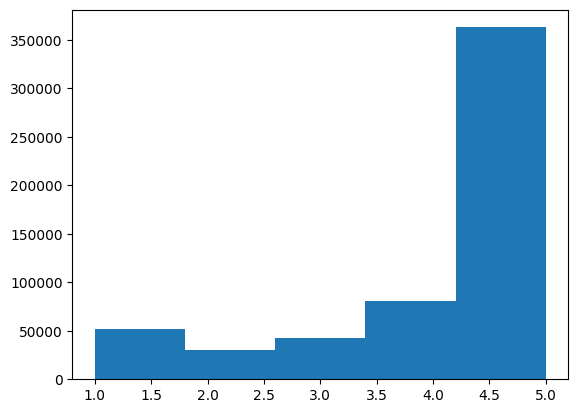

Score
1     52264
2     29743
3     42638
4     80654
5    363102
Name: Id, dtype: int64


In [ ]:
review.Score.hist(bins=5,grid=False)
plt.show()
print(review.groupby('Score').Id.count())

In [ ]:
score1 = review[review['Score'] == 1].sample(n=29743)
score2 = review[review['Score'] == 2].sample(n=29743)
score3 = review[review['Score'] == 3].sample(n=29743)
score4 = review[review['Score'] == 4].sample(n=29743)
score5 = review[review['Score'] == 5].sample(n=29743)

In [ ]:
review_s = pd.concat([score1,score2,score3,score4,score5],axis=0)
review_s.reset_index(drop=True,inplace=True)

In [ ]:
review_s.shape

(148715, 10)

In [ ]:
print(review_s.groupby('Score').count().Id)

Score
1    29743
2    29743
3    29743
4    29743
5    29743
Name: Id, dtype: int64


In [ ]:
from wordcloud import WordCloud
from wordcloud import STOPWORDS

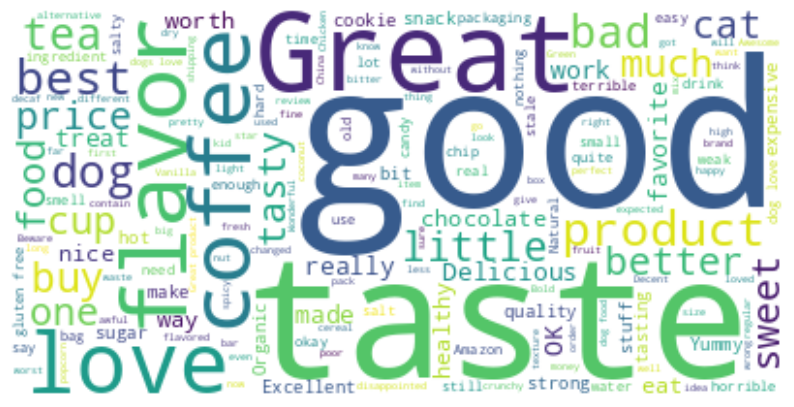

In [ ]:
reviews = review_s.Summary.str.cat()
wc = WordCloud(background_color='white').generate(reviews)
plt.figure(figsize=(10,10))
plt.imshow(wc,interpolation='bilinear')
plt.axis("off")
plt.show()

In [ ]:
review_s[review_s['Score']==1]['Text'].loc[0]

"My son LOVES HappyBellies Oatmeal, I tried Multigrain loved it, too. So I, I read ingredient noticed added glucose make cereal sweet. No extra sugar darling. Back oatmeal version u since naturally sweet. As he's 10 month old, I'm exposing grains, like quinoa (which multigrain)and complementing daily grain HB oatmeal get good vitamin probiotic DHA."

In [ ]:
negative =review_s[review_s['Score'].isin([1,2])]
positive = review_s[review_s['Score'].isin([4,5])]
ng = negative.Summary.str.cat()
po = positive.Summary.str.cat()

In [ ]:
wc = WordCloud(background_color='white').generate(ng)
wc1 = WordCloud(background_color='white').generate(po)


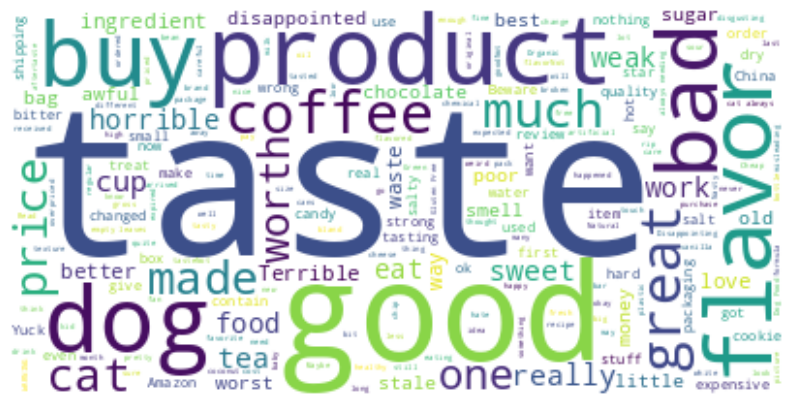

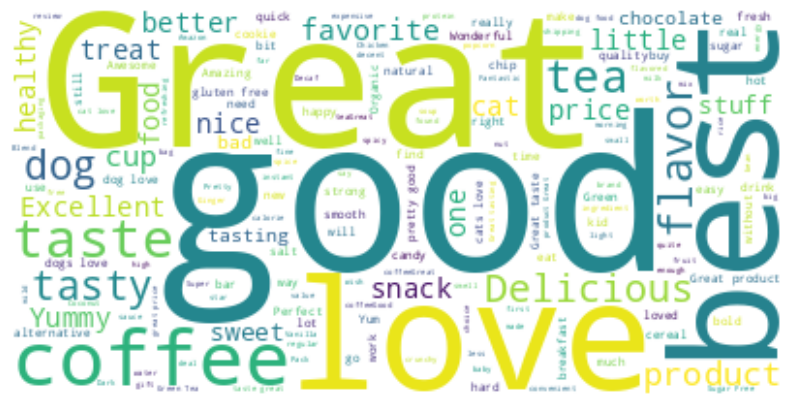

In [ ]:
plt.figure(figsize=(10,10))
plt.imshow(wc,interpolation='bilinear')
plt.axis("off")
plt.show()
plt.figure(figsize=(10,10))
plt.imshow(wc1,interpolation='bilinear')
plt.axis("off")
plt.show()

In [ ]:
pip install vaderSentiment

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.0/126.0 kB 9.6 MB/s eta 0:00:00


In [ ]:
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
from tqdm import tqdm

In [ ]:
ay = SentimentIntensityAnalyzer()
emp = []
for row in tqdm(df['Text'][0:50000], total=len(df),desc='Analyzing Sentiment'):
  vs = ay.polarity_scores(row)
  emp.append(vs)
dfs = pd.DataFrame(emp)
dfs.head()


Analyzing Sentiment:   9%|▉         | 50000/568401 [00:34<06:01, 1433.02it/s]


,neg,neu,pos,compound
0,0.000,0.556,0.444,0.9413
1,0.092,0.801,0.106,0.0762
2,0.107,0.661,0.232,0.8532
3,0.000,0.896,0.104,0.4404
4,0.000,0.417,0.583,0.9468


In [ ]:
import numpy as np
np.where(dfs['compound'] >= 0, 'Positive','negative')

array(['Positive', 'Positive', 'Positive', ..., 'Positive', 'negative',
       'Positive'], dtype='<U8')

In [ ]:
c = df[0:50000]

In [ ]:
c['sentiment'] = np.where(dfs['compound'] >= 0,'positive','Negative')

<ipython-input-146-e2e6b394e80c>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  c['sentiment'] = np.where(dfs['compound'] >= 0,'positive','Negative')


In [ ]:
c

,Id,ProductId,UserId,ProfileName,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,Summary,Text,sentiment
0,1,B001E4KFG0,A3SGXH7AUHU8GW,delmartian,1,1,5,1303862400,Good Quality Dog Food,I bought several Vitality canned dog food prod...,positive
1,2,B00813GRG4,A1D87F6ZCVE5NK,dll pa,0,0,1,1346976000,Not as Advertised,Product arrived labeled Jumbo Salted Peanuts.....,positive
2,3,B000LQOCH0,ABXLMWJIXXAIN,"Natalia Corres ""Natalia Corres""",1,1,4,1219017600,"""Delight"" says it all","This confection around centuries. It light, pi...",positive
3,4,B000UA0QIQ,A395BORC6FGVXV,Karl,3,3,2,1307923200,Cough Medicine,If looking secret ingredient Robitussin I beli...,positive
4,5,B006K2ZZ7K,A1UQRSCLF8GW1T,"Michael D. Bigham ""M. Wassir""",0,0,5,1350777600,Great taffy,Great taffy great price. There wide assortment...,positive
...,...,...,...,...,...,...,...,...,...,...,...
50002,50003,B0019EY7KA,A1X2GWDA6TTWY8,P. SOO,23,23,5,1258848000,"smooth, soft and tasty",I've using Satin Ice year cakes. I purchase lo...,positive
50003,50004,B0019EY7KA,A258FXO3O8EQQE,Roberta A. Ryherd,20,20,5,1239408000,Best fondant!,Satin Ice best tasting fondant I find market. ...,positive
50004,50005,B0019EY7KA,A1VIG3C5YGWYAU,Laura,2,2,5,1317168000,Quick Delivery and Very Easy to work with!,I complete wedding cake needed black fondant. ...,positive
50005,50006,B0019EY7KA,A1V44WCLV1CVIV,C. RAMOS,0,0,2,1334275200,Quality suffering. Cracks abound.,"I using Satin Ice many years, lately, quality ...",Negative


In [ ]:
c['sentiment'].value_counts()

,count
sentiment,
positive,46240
Negative,3760


<Axes: xlabel='ProductId,sentiment'>

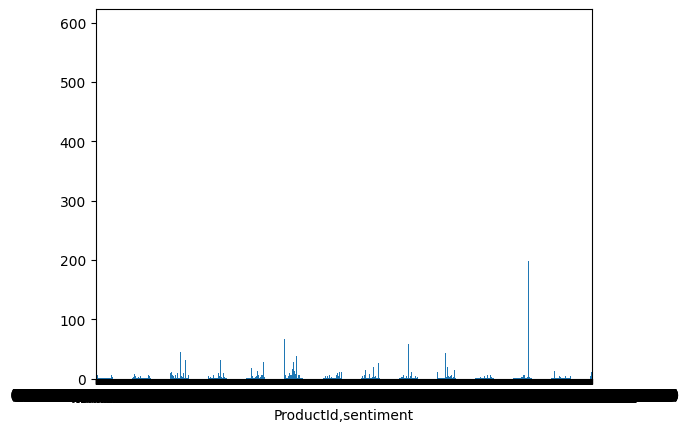

In [ ]:
result = c.groupby('ProductId')['sentiment'].value_counts()
result.plot(kind='bar',rot=0)

In [ ]:
g = c.groupby('ProductId').sentiment.count()
g.head()

,sentiment
ProductId,
2734888454,2
B00002NCJC,2
B00002Z754,2
B00005V3DC,3
B000084DVR,2


<Axes: xlabel='sentiment'>

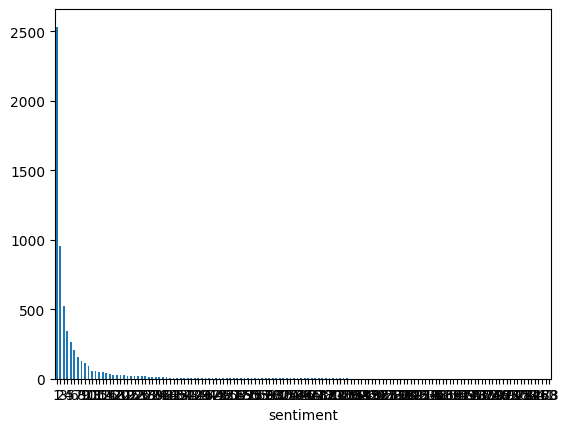

In [ ]:
re = g.value_counts()
re.plot(kind='bar',rot=0)